In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_stata('ECON0019_empirical_project_2026.dta')

In [3]:
# Define regressand log(viorate)
df['log_viorate'] = np.log(df['viorate'])

In [8]:
# Summary statistics (mean, quantile, standard deviation)
summary = df.groupby('year')[['shallcarry','log_viorate']].describe()
display(summary)

shallcarry                                              log_viorate  \
          count      mean       std  min  25%  50%  75%  max       count   
year                                                                       
77         51.0  0.078431  0.271524  0.0  0.0  0.0  0.0  1.0        51.0   
78         51.0  0.078431  0.271524  0.0  0.0  0.0  0.0  1.0        51.0   
79         51.0  0.078431  0.271524  0.0  0.0  0.0  0.0  1.0        51.0   
80         51.0  0.078431  0.271524  0.0  0.0  0.0  0.0  1.0        51.0   
81         51.0  0.078431  0.271524  0.0  0.0  0.0  0.0  1.0        51.0   
82         51.0  0.098039  0.300327  0.0  0.0  0.0  0.0  1.0        51.0   
83         51.0  0.098039  0.300327  0.0  0.0  0.0  0.0  1.0        51.0   
84         51.0  0.098039  0.300327  0.0  0.0  0.0  0.0  1.0        51.0   
85         51.0  0.098039  0.300327  0.0  0.0  0.0  0.0  1.0        51.0   
86         51.0  0.137255  0.347540  0.0  0.0  0.0  0.0  1.0        51.0   
87         51.0  0.156863  0.367290  0.0  0.0  0.0  0.0  1.0        51.0   
88         51.0  0.176471  0.385013  0.0  0.0  0.0  0.0  1.0        51.0   
89         51.0  0.176471  0.385013  0.0  0.0  0.0  0.0  1.0        51.0   
90         51.0  0.235294  0.428403  0.0  0.0  0.0  0.0  1.0        51.0   
91         51.0  0.294118  0.460179  0.0  0.0  0.0  1.0  1.0        51.0   
92         51.0  0.333333  0.476095  0.0  0.0  0.0  1.0  1.0        51.0   
93         51.0  0.333333  0.476095  0.0  0.0  0.0  1.0  1.0        51.0   
94         51.0  0.333333  0.476095  0.0  0.0  0.0  1.0  1.0        51.0   
95         51.0  0.411765  0.497050  0.0  0.0  0.0  1.0  1.0        51.0   
96         51.0  0.509804  0.504878  0.0  0.0  1.0  1.0  1.0        51.0   
97         51.0  0.568627  0.500196  0.0  0.0  1.0  1.0  1.0        51.0   
98         51.0  0.568627  0.500196  0.0  0.0  1.0  1.0  1.0        51.0   
99         51.0  0.568627  0.500196  0.0  0.0  1.0  1.0  1.0        51.0   

                                                                            
          mean       std       min       25%       50%       75%       max  
year                                                                        
77    5.820357  0.569906  4.206184  5.460624  5.926659  6.167518  7.262979  
78    5.868742  0.574670  4.204693  5.534690  5.946990  6.214998  7.252550  
79    5.964074  0.586964  4.115780  5.667117  6.025866  6.313566  7.383182  
80    6.008163  0.618579  3.988984  5.708418  6.077642  6.401665  7.606188  
81    5.997814  0.643853  4.212128  5.657331  6.090631  6.433209  7.729648  
82    5.956297  0.652230  4.123903  5.606271  6.042871  6.383602  7.660633  
83    5.898623  0.633728  3.983413  5.502517  5.986201  6.336517  7.557682  
84    5.909398  0.613746  3.981549  5.479970  6.000424  6.264724  7.450951  
85    5.936891  0.624103  3.850147  5.547518  6.042395  6.339021  7.393140  
86    5.990757  0.647252  3.937691  5.599809  6.056784  6.432853  7.316748  
87    5.967084  0.641366  4.039536  5.585488  6.043345  6.387344  7.384176  
88    6.007331  0.667265  4.079231  5.640215  6.113682  6.455019  7.560914  
89    6.043398  0.672558  4.146304  5.615897  6.160574  6.469901  7.669448  
90    6.143478  0.676836  4.302713  5.716175  6.262445  6.587170  7.807185  
91    6.177821  0.703041  4.180522  5.746480  6.326686  6.620736  7.805189  
92    6.196230  0.688053  4.422449  5.794902  6.283201  6.630757  7.949021  
93    6.207125  0.687127  4.409155  5.827188  6.243390  6.650364  7.979955  
94    6.182824  0.680737  4.404277  5.816292  6.254982  6.614319  7.887058  
95    6.168047  0.659756  4.462454  5.872819  6.258434  6.578177  7.886608  
96    6.106428  0.651009  4.430817  5.787358  6.190930  6.486529  7.811893  
97    6.082694  0.633291  4.468204  5.784115  6.150603  6.493505  7.612930  
98    6.026906  0.619777  4.492002  5.739308  6.066108  6.444919  7.449207  
99    5.967261  0.605986  4.203199  5.646439  6.020781  6.349916  7.394923

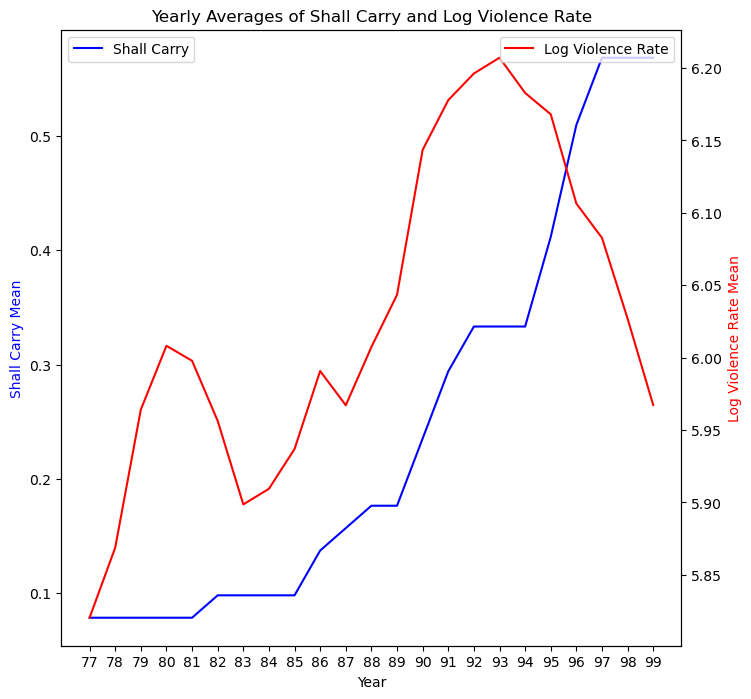

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate yearly averages - group by year first
yearly_means = df.groupby('year').agg({
    'shallcarry': 'mean',
    'log_viorate': 'mean',
    'viorate': 'mean'
}).reset_index()

# Create the dual-axis plot
fig, ax1 = plt.subplots(figsize=(8,8))
ax2 = ax1.twinx()

# Now plot with data that has matching dimensions
ax1.plot(yearly_means['year'], yearly_means['shallcarry'], color='blue', label='Shall Carry')
ax2.plot(yearly_means['year'], yearly_means['log_viorate'], color='red', label='Log Violence Rate')

# Add labels and legend
ax1.set_xlabel('Year')
ax1.set_ylabel('Shall Carry Mean', color='blue')
ax2.set_ylabel('Log Violence Rate Mean', color='red')

# Increase the interval of the x-axis
# Get the min and max years
min_year = yearly_means['year'].min()
max_year = yearly_means['year'].max()

step = 1
xticks = np.arange(min_year, max_year + 1, step)
ax1.set_xticks(xticks)

# Create legends for both axes
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title('Yearly Averages of Shall Carry and Log Violence Rate')
plt.show()